## Which circuit(s) are the most difficult to finish?

To measure difficulty, we will take a track's median lap time and scale that by the track length to account for different circuit lengths which is the average rate.
<br>
We will also be looking at races from 2014 - 2016. This is to account for improvements in racing technology -- for example, race cars in 2008 would differ from cars in 2015 which would make lap times drastically different -- and different lap lengths. 2014–2016 is an ideal window for analyzing trends because car architecture, engine philosophy, and tire characteristics remained consistent without the confounding effects of major regulation resets.
<br>



##### Import packages

In [100]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

##### Read in csv files

In [101]:
races = pd.read_csv('1-Formula_One/races.csv')
circuits = pd.read_csv('1-Formula_One/circuits.csv')
df_time = pd.read_csv('1-Formula_One/lap_times.csv')
df_length = pd.read_csv('1-Formula_One/circuit_length.csv')

### Getting track lengths

Since the F1 datasets don't include any data on track length, we will need to append the track length data ourselves.
<br>
First, we will filter for races from 2014 to 2016 for our analysis. Then we will use the `raceId` column to filter for those races from our time dataframe.

In [102]:
races_1416 = races.query('2014 <= year <= 2016')

In [103]:
# get race IDs from 2014 - 2016 and 
unique_raceID = races_1416['raceId'].unique()

df_time1416 = df_time.query('raceId in @unique_raceID')

# map circuit to race
race_lookup = races.set_index('raceId')['circuitId']
df_time1416['circuitId'] = df_time1416['raceId'].map(race_lookup)

display(df_time1416)


C:\Users\aliso\AppData\Local\Temp\ipykernel_30268\3915810556.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time1416['circuitId'] = df_time1416['raceId'].map(race_lookup)


,raceId,driverId,lap,position,time,milliseconds,circuitId
72130,900,3,1,1,1:42.038,102038,1
72131,900,3,2,1,1:37.687,97687,1
72132,900,3,3,1,1:35.765,95765,1
72133,900,3,4,1,1:34.939,94939,1
72134,900,3,5,1,1:35.438,95438,1
...,...,...,...,...,...,...,...
406321,968,825,1,22,2:05.231,125231,24
406322,968,825,2,22,2:13.467,133467,24
406323,968,825,3,22,1:48.744,108744,24
406324,968,825,4,22,1:48.601,108601,24


In [ ]:
# get counts 
df_counts = df_time1416.groupby('circuitId').size().reset_index(name='n')

# get mean and standard deviation lap time in milliseconds per circuit
df_average = (df_time1416.groupby('circuitId').
agg(avg_ms = ('milliseconds','mean'),
    std_ms = ('milliseconds','std')).
sort_values(by='circuitId',ascending=True))
# use standard deviation to calculate standard error for visualization
df_average['se_ms'] = df_average['std_ms'] / np.sqrt(df_counts['n'])


#get average track length from 2014-2016 per circuit
df_length_avg = (df_length.groupby('circuitId')['circuit_length'].mean().reset_index().sort_values(by='circuitId',ascending=True))
# merge the average dfs together
df_avg = pd.merge(df_average, df_length_avg, on='circuitId', how='left')

display(df_avg)



    circuitId     n
0           1  2667
1           2  2962
2           3  3134
3           4  3837
4           6  4066
5           7  3876
6           9  2611
7          10  2726
8          11  4044
9          13  2350
10         14  3039
11         15  3376
12         17  3375
13         18  3850
14         22  3106
15         24  3053
16         32  2740
17         69  2767
18         70  3931
19         71  2851
20         73  1028


,circuitId,avg_ms,std_ms,se_ms,circuit_length
0,1,105309.806899,92513.159143,1699.851506,5.303000
1,2,108792.127279,10179.344381,181.831998,5.543000
2,3,102922.829292,8173.963890,131.958331,5.412000
3,4,94071.382069,5925.628847,92.928892,4.655000
4,6,88766.598623,14654.337580,286.789176,3.338000
5,7,81948.840299,8727.240477,167.152939,4.361000
6,9,135649.708924,313256.069119,6461.979304,5.891000
7,10,84115.034850,5770.523961,104.676670,4.574000
8,11,93015.229970,11364.208345,195.586092,4.381000
9,13,126613.017447,87919.947337,1416.958251,7.004000


In [112]:
#merge track length and average lap time
df_length = df_length[['circuitId','circuit_name']].drop_duplicates()
df_final = pd.merge(df_avg,df_length,
                     on='circuitId',
                     how='left')

# rearrange columns and rename to make the dataframe look nicer
df_final = df_final[['circuitId','circuit_name','avg_ms','se_ms','circuit_length']]
df_final = df_final.rename(columns = {'circuit_length' : 'avg_km'})
display(df_final)

,circuitId,circuit_name,avg_ms,se_ms,avg_km
0,1,Albert Park Grand Prix Circuit,105309.806899,1699.851506,5.303000
1,2,Sepang International Circuit,108792.127279,181.831998,5.543000
2,3,Bahrain International Circuit,102922.829292,131.958331,5.412000
3,4,Circuit de Barcelona-Catalunya,94071.382069,92.928892,4.655000
4,6,Circuit de Monaco,88766.598623,286.789176,3.338000
5,7,Circuit Gilles Villeneuve,81948.840299,167.152939,4.361000
6,9,Silverstone Circuit,135649.708924,6461.979304,5.891000
7,10,Hockenheimring,84115.034850,104.676670,4.574000
8,11,Hungaroring,93015.229970,195.586092,4.381000
9,13,Circuit de Spa-Francorchamps,126613.017447,1416.958251,7.004000


### Determining the most difficult tracks

In [114]:
# find ms/km for each track
df_final['avg_ms_per_km'] = df_final['avg_ms']/df_final['avg_km']
df_final['se_ms_per_km'] = df_final['se_ms']/df_final['avg_km']
df_final_sorted = df_final.sort_values(by='avg_ms_per_km',ascending=False)

display(df_final_sorted)

,circuitId,circuit_name,avg_ms,se_ms,avg_km,avg_ms_per_km,se_ms_per_km
4,6,Circuit de Monaco,88766.598623,286.789176,3.338000,26592.749737,85.916470
13,18,Autódromo José Carlos Pace,103386.212208,2760.345369,4.309000,23993.087075,640.599993
11,15,Marina Bay Street Circuit,119337.510664,256.177568,5.063667,23567.410440,50.591317
6,9,Silverstone Circuit,135649.708924,6461.979304,5.891000,23026.601413,1096.924003
8,11,Hungaroring,93015.229970,195.586092,4.381000,21231.506499,44.644166
17,69,Circuit of the Americas,111773.501626,NaN,5.513000,20274.533217,NaN
3,4,Circuit de Barcelona-Catalunya,94071.382069,92.928892,4.655000,20208.674988,19.963242
16,32,Autódromo Hermanos Rodríguez,86788.720438,NaN,4.304000,20164.665529,NaN
14,22,Suzuka Circuit,116992.621700,NaN,5.807000,20146.826537,NaN
0,1,Albert Park Grand Prix Circuit,105309.806899,1699.851506,5.303000,19858.534207,320.545259


Text(0.5, 1.0, 'Top 5 most difficult circuits by average speed')

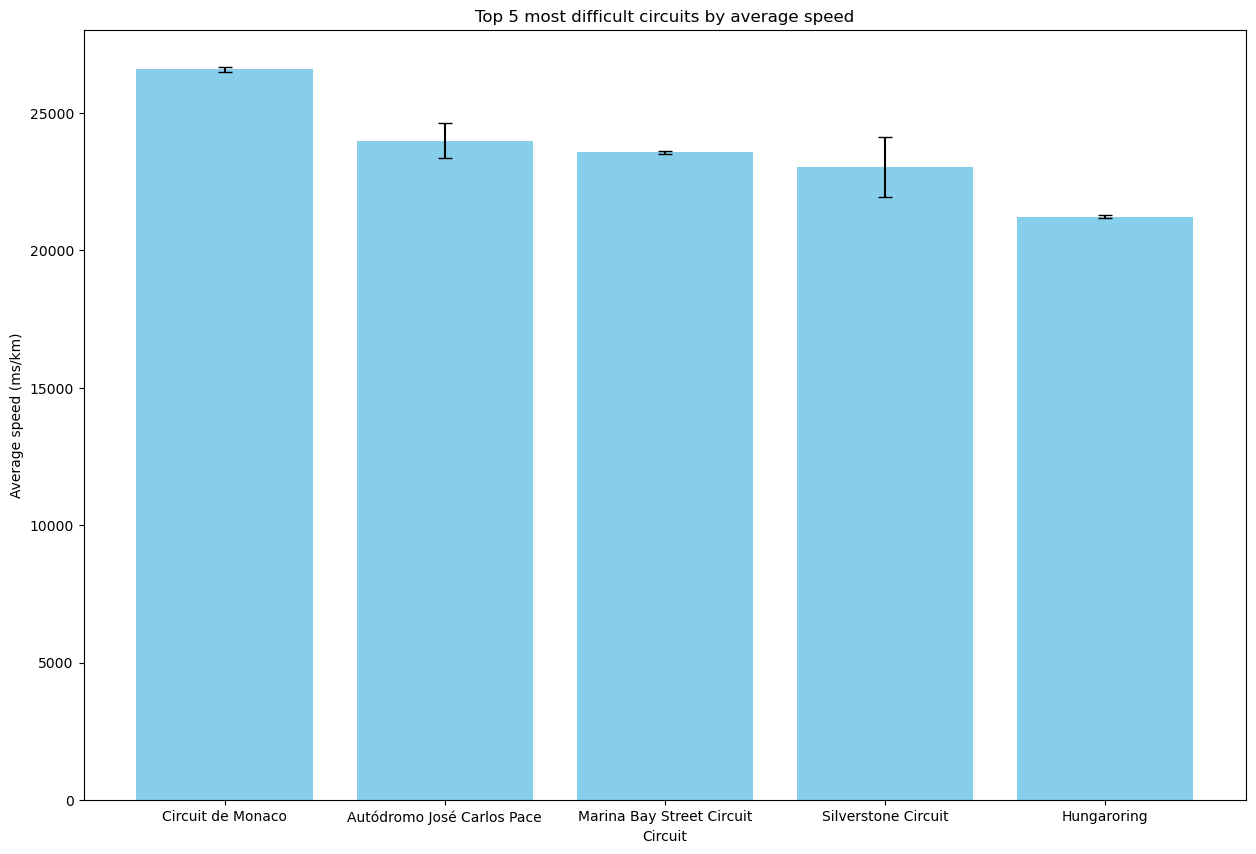

In [124]:
# plot
df_plot = df_final_sorted.head(5)

plt.figure(figsize=(15,10))
plt.bar(
    df_plot["circuit_name"],
    df_plot["avg_ms_per_km"],
    yerr=df_plot["se_ms_per_km"],  
    capsize=5,                     
    color='skyblue'
)
plt.xlabel('Circuit')
plt.ylabel('Average speed (ms/km)')
plt.title('Top 5 most difficult circuits by average speed')


### Supplement: Creating the track length csv

To create `circuit_length.csv`, necessary columns were selected to create a new dataframe `df race circuit`that made filling in data manually easier. `raceId` and `year` were selected in the event a race in another year had a track that had different lengths compared to the other years. Then, the `name` column from `circuits.csv` was mapped to the circuit IDs in the new dataframe.

In [99]:
df_racecircuit = races_1416[['raceId','year','circuitId','name']]

#create column of circuit name from circuit df
circuit_map = circuits.set_index("circuitId")["name"]
df_racecircuit["circuit_name"] = df_racecircuit["circuitId"].map(circuit_map)

display(df_racecircuit)

df_racecircuit.to_csv('circuit_length.csv',index=False)

C:\Users\aliso\AppData\Local\Temp\ipykernel_30268\3211409759.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_racecircuit["circuit_name"] = df_racecircuit["circuitId"].map(circuit_map)


,raceId,year,circuitId,name,circuit_name
897,900,2014,1,Australian Grand Prix,Albert Park Grand Prix Circuit
898,901,2014,2,Malaysian Grand Prix,Sepang International Circuit
899,902,2014,3,Bahrain Grand Prix,Bahrain International Circuit
900,903,2014,17,Chinese Grand Prix,Shanghai International Circuit
901,904,2014,4,Spanish Grand Prix,Circuit de Barcelona-Catalunya
902,905,2014,6,Monaco Grand Prix,Circuit de Monaco
903,906,2014,7,Canadian Grand Prix,Circuit Gilles Villeneuve
904,907,2014,70,Austrian Grand Prix,Red Bull Ring
905,908,2014,9,British Grand Prix,Silverstone Circuit
906,909,2014,10,German Grand Prix,Hockenheimring


After exporting the empty csv, circuit lengths in km were added in manually in Excel. Track data came from the Wikipedia articles linked in `circuits.csv`. The dataframe was then re-imported back in as `circuit_length.csv`